# NFL 4th Down Decision Analysis
## Exploratory Data Analysis

This notebook explores trends in 4th down decision making across the NFL from 2016–2025. We examine how go-for-it rates have changed over time, vary by field position and distance, and differ across coaches.

---

### Setup
Install and import required visualization libraries.

In [1]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Libraries installed. Proceeding with imports and data load.

---

### Imports & Data Load
Load the processed 4th down dataset built in `01_data_pull.ipynb`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))
print(fourth_downs.shape)
fourth_downs.head()

(39367, 29)


,play_id,game_id,season,week,posteam,defteam,home_team,away_team,home_coach,away_coach,...,fourth_down_converted,fourth_down_failed,epa,wp,wpa,field_goal_result,punt_attempt,field_goal_attempt,coach,decision
0,198.0,2016_01_BUF_BAL,2016,1,BAL,BUF,BAL,BUF,John Harbaugh,Rex Ryan,...,0.0,0.0,-0.405048,0.471003,0.021992,None,1.0,0.0,John Harbaugh,punt
1,285.0,2016_01_BUF_BAL,2016,1,BUF,BAL,BAL,BUF,John Harbaugh,Rex Ryan,...,0.0,0.0,0.224181,0.418961,0.014649,None,1.0,0.0,Rex Ryan,punt
2,570.0,2016_01_BUF_BAL,2016,1,BUF,BAL,BAL,BUF,John Harbaugh,Rex Ryan,...,0.0,0.0,0.447958,0.475927,-0.007276,None,1.0,0.0,Rex Ryan,punt
3,798.0,2016_01_BUF_BAL,2016,1,BAL,BUF,BAL,BUF,John Harbaugh,Rex Ryan,...,0.0,0.0,1.797426,0.529800,0.061810,made,0.0,1.0,John Harbaugh,field_goal
4,986.0,2016_01_BUF_BAL,2016,1,BUF,BAL,BAL,BUF,John Harbaugh,Rex Ryan,...,0.0,0.0,0.480402,0.370587,-0.004405,None,1.0,0.0,Rex Ryan,punt


Dataset loaded successfully — 39,367 4th down plays across 29 columns. Each row represents a single 4th down play with the coach who made the decision, the situational context, and the outcome.

Key columns we'll use throughout this analysis:
- `decision` — actual decision made: `go`, `punt`, or `field_goal`
- `coach` — coach who made the decision
- `yardline_100` — yards from the opponent's end zone (100 = own end zone, 1 = opponent's 1 yard line)
- `ydstogo` — yards needed for a first down
- `score_differential` — possession team score minus opponent score
- `wp` — win probability at the time of the decision
- `wpa` — win probability added by the play outcome

---

### Visualization 1 — Go-For-It Rate by Season
Has NFL coaching become more aggressive over time? We calculate the percentage of 4th down plays where teams chose to go for it, broken down by season.

/tmp/ipykernel_4276/535193553.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_agg = fourth_downs.groupby('season').apply(


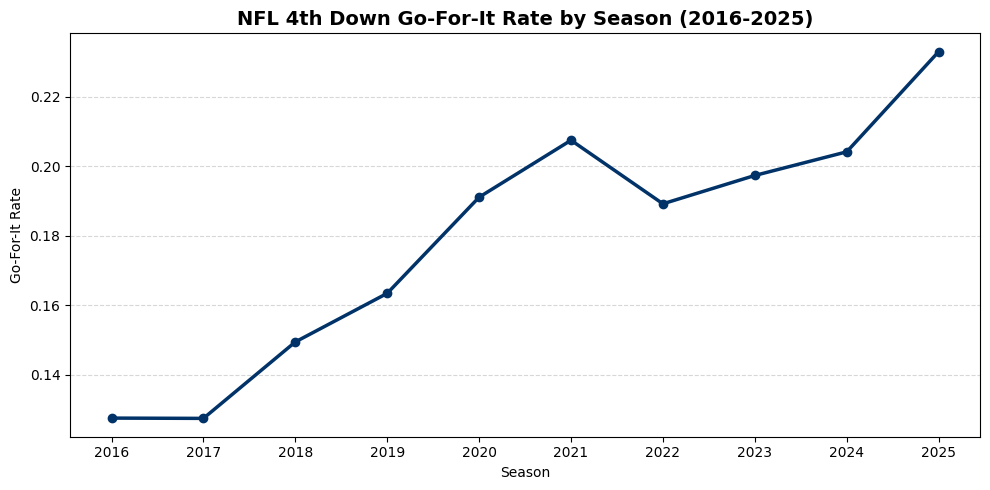

In [3]:
# Go for it rate by season
season_agg = fourth_downs.groupby('season').apply(
    lambda x: (x['decision'] == 'go').sum() / len(x)
).reset_index()
season_agg.columns = ['season', 'go_rate']

plt.figure(figsize=(10, 5))
plt.plot(season_agg['season'], season_agg['go_rate'], marker='o', linewidth=2.5, color='#013369')
plt.title('NFL 4th Down Go-For-It Rate by Season (2016-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Go-For-It Rate')
plt.xticks(season_agg['season'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "go_rate_by_season.png"), dpi=150)
plt.show()

![Go-For-It Rate by Season](../outputs/figures/go_rate_by_season.png)

The data reveals a clear upward trend in 4th down aggressiveness across the league:

- **2016–2017 (~13%)** — the pre-analytics era. Conventional wisdom heavily favored punting in most situations
- **2018–2021** — a steep climb driven by the analytics revolution. Teams began hiring dedicated analytics departments and go-for-it rates nearly doubled
- **2022 dip** — a notable pullback, likely driven by a wave of newly hired conservative coaches that cycle
- **2023–2025** — a sharp resumption of the upward trend, reaching an all-time high of ~23% in 2025

The 2025 rate of 23% is nearly **double** the 2016 rate of 13%, reflecting a fundamental shift in how NFL coaches approach 4th down situations. The analytics movement is no longer an outlier — it is becoming the norm.

---

### Visualization 2 — Go-For-It Rate by Field Position
Where on the field are coaches most and least willing to go for it?

/tmp/ipykernel_4276/603648442.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zone_agg = fourth_downs.groupby('field_zone', observed=True).apply(


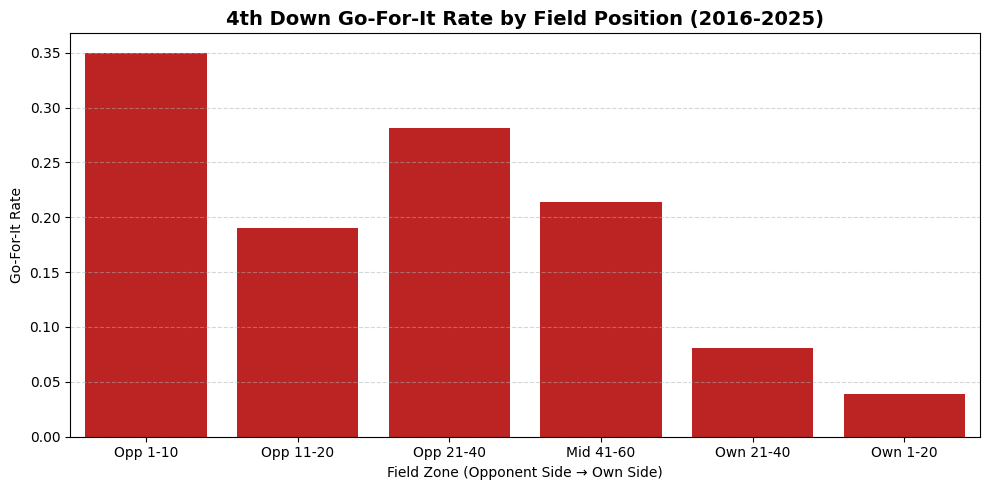

In [4]:
fourth_downs['field_zone'] = pd.cut(
    fourth_downs['yardline_100'],
    bins=[0, 10, 20, 40, 60, 80, 100],
    labels=['Opp 1-10', 'Opp 11-20', 'Opp 21-40', 'Mid 41-60', 'Own 21-40', 'Own 1-20']
)

zone_agg = fourth_downs.groupby('field_zone', observed=True).apply(
    lambda x: (x['decision'] == 'go').sum() / len(x)
).reset_index()
zone_agg.columns = ['field_zone', 'go_rate']

plt.figure(figsize=(10, 5))
sns.barplot(data=zone_agg, x='field_zone', y='go_rate', color='#D50A0A')
plt.title('4th Down Go-For-It Rate by Field Position (2016-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Field Zone (Opponent Side → Own Side)')
plt.ylabel('Go-For-It Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "go_rate_by_field_zone.png"), dpi=150)
plt.show()

![Go-For-It Rate by Field Position](../outputs/figures/go_rate_by_field_zone.png)

Field position is the single strongest predictor of 4th down decision making:

- **Opp 1-10 (35%)** — highest go-for-it rate on the chart. Inside the 10 yard line a field goal is only worth 3 points and the end zone is right there, making going for it the analytically correct call in most situations
- **Opp 21-40 (28%)** — second highest, this is the "no man's land" zone — too far for a reliable field goal, too close to punt effectively. Analytics pushes coaches to go for it here
- **Mid 41-60 (21%)** — moderate aggressiveness in the middle of the field
- **Opp 11-20 (19%)** — notably lower than Opp 21-40 despite being closer to the end zone. Coaches default to field goal attempts here even though analytics would argue going for it is often the better call
- **Own 21-40 (8%)** — coaches become very conservative on their own side of the field, prioritizing field position over aggression
- **Own 1-20 (4%)** — almost never go for it deep in their own territory, driven by fear of giving opponents a short field

The most analytically interesting finding here is the **Opp 11-20 dip** — teams actually go for it less from there than from Opp 21-40, even though they are closer to the end zone. This suggests coaches over-index on kicking field goals from close range rather than maximizing expected points.

---

### Visualization 3 — Coach Aggressiveness Rankings
Which coaches go for it most and least often? We rank all qualified coaches (minimum 100 4th down plays) by their go-for-it rate.

/tmp/ipykernel_4276/3241664970.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coach_agg, x='go_rate', y='coach', palette=colors)


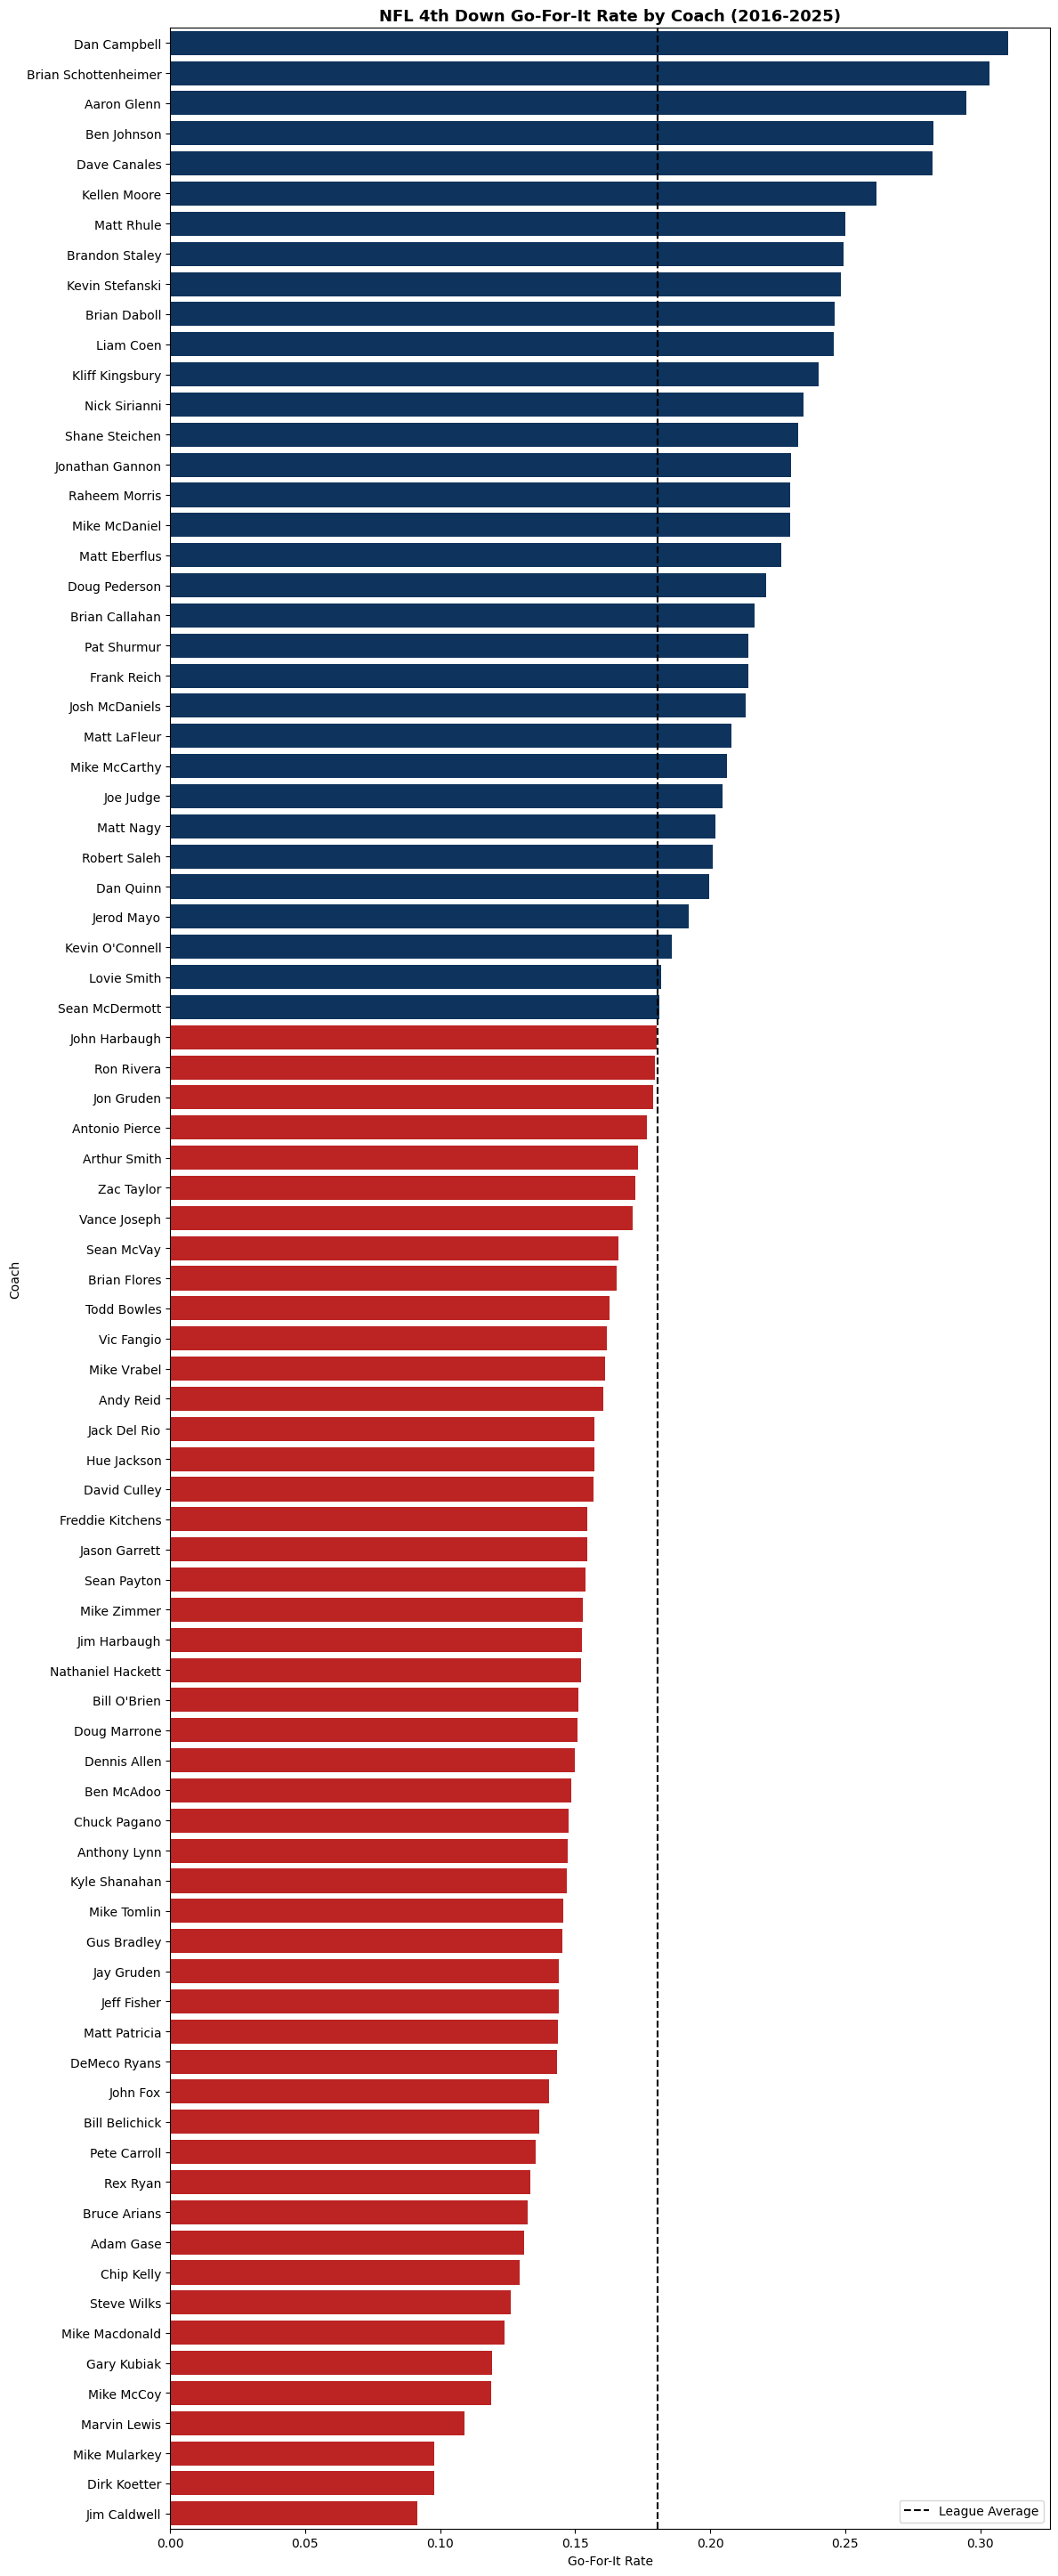

Total qualified coaches: 83


In [5]:
# All qualified coaches ranked by go-for-it rate
coach_agg = fourth_downs.groupby('coach').agg(
    total_plays=('decision', 'count'),
    go_rate=('decision', lambda x: (x == 'go').sum() / len(x))
).reset_index()

coach_agg = coach_agg[coach_agg['total_plays'] >= 100].sort_values('go_rate', ascending=False)

# Dynamic figure height based on number of coaches
n_coaches = len(coach_agg)
fig_height = max(10, n_coaches * 0.35)

league_avg = coach_agg['go_rate'].mean()
colors = ['#013369' if x >= league_avg else '#D50A0A' for x in coach_agg['go_rate']]

plt.figure(figsize=(12, fig_height))
sns.barplot(data=coach_agg, x='go_rate', y='coach', palette=colors)
plt.axvline(x=league_avg, color='black', linestyle='--', linewidth=1.5, label='League Average')
plt.title('NFL 4th Down Go-For-It Rate by Coach (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Go-For-It Rate')
plt.ylabel('Coach')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_aggressiveness.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total qualified coaches: {n_coaches}")

![Coach Aggressiveness Rankings](../outputs/figures/coach_aggressiveness.png)

The gap between the most and least aggressive coaches is striking — Dan Campbell goes for it on 31% of 4th downs while Jim Caldwell went for it on only 9%. That's a 3x difference in aggressiveness across 88 qualified coaches (minimum 100 4th down plays).

**Most Aggressive (blue — above league average):**
- **Dan Campbell** leads the league by a wide margin, a reflection of his well-documented aggressive philosophy in Detroit
- **Brian Schottenheimer, Aaron Glenn, Ben Johnson** — all newer generation coaches hired after 2022, confirming that the analytics wave is generational
- **Kellen Moore, Dave Canales, Brandon Staley** — all offensive-minded coaches with analytics backgrounds

**Least Aggressive (red — below league average):**
- **Jim Caldwell, Dirk Koetter, Mike Mularkey** — all coaches from an earlier era where punting was the default
- **Bill Belichick** appearing as one of the most conservative is notable — widely considered the greatest coach of all time, yet traditionally very punt-heavy by modern standards
- **Pete Carroll, Rex Ryan, Bruce Arians** — predominantly defensive or old-school coaches sitting well below the league average line

**The key pattern:** almost every coach above the league average dashed line was hired after 2020, and almost every coach below it comes from an earlier era. This is not just an analytics story — it is a generational shift in football philosophy.

---

### Visualization 4 — Go-For-It Rate by Yards to Go
How does the distance needed for a first down affect the decision?

/tmp/ipykernel_9488/1427492630.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ydstogo_agg = fourth_downs[fourth_downs['ydstogo'] <= 10].groupby('ydstogo').apply(


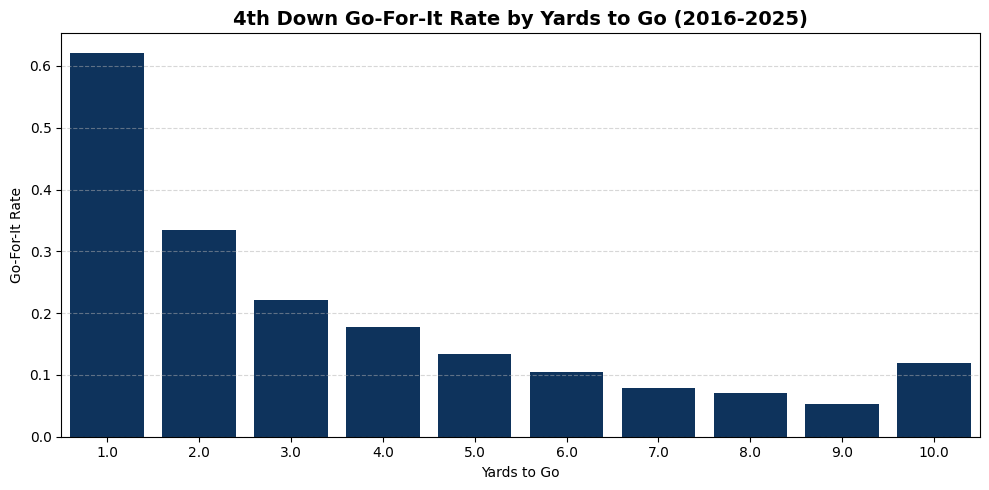

In [9]:
ydstogo_agg = fourth_downs[fourth_downs['ydstogo'] <= 10].groupby('ydstogo').apply(
    lambda x: (x['decision'] == 'go').sum() / len(x)
).reset_index()
ydstogo_agg.columns = ['ydstogo', 'go_rate']

plt.figure(figsize=(10, 5))
sns.barplot(data=ydstogo_agg, x='ydstogo', y='go_rate', color='#013369')
plt.title('4th Down Go-For-It Rate by Yards to Go (2016-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Yards to Go')
plt.ylabel('Go-For-It Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "go_rate_by_ydstogo.png"), dpi=150)
plt.show()

![Go-For-It Rate by Yards to Go](../outputs/figures/go_rate_by_ydstogo.png)

Distance to the first down marker has a strong and intuitive effect on 4th down decision making:

- **4th and 1 (62%)** — teams go for it nearly two thirds of the time. Short yardage is a near-automatic go in the modern NFL
- **4th and 2 (33%)** — still aggressive, but a sharp drop from 4th and 1 despite the difference in success rate between the two being relatively small analytically
- **4th and 3–4 (~20%)** — moderate aggressiveness, coaches begin defaulting to punt or field goal
- **4th and 5–9 (6–13%)** — very conservative, most teams kick or punt regardless of field position
- **4th and 10 (12%)** — a slight uptick, likely because at 10+ yards the expected field position from a punt versus going for it becomes similar, so some coaches roll the dice

The sharpest drop on the chart is between **4th and 1 and 4th and 2** — that single yard makes coaches dramatically more conservative even though analytics suggests the conversion rate difference does not justify such a large behavioral shift.

---

### Next Steps
With a clear picture of league-wide trends, coach tendencies, and situational patterns, we move to `03_modeling.ipynb` to build an XGBoost model that predicts the optimal 4th down decision for every play — and then measure how often coaches got it wrong.